# Exploratory Data Analysis
Assumes `sales_preprocessed_weekly_model.csv` is available (output of preprocessing.ipynb).

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df_model = pd.read_csv("sales_preprocessed_weekly.csv", parse_dates=['week_start'])

print("Shape:", df_model.shape)
print("Products:", df_model['product_id'].nunique())
print("Date range:", df_model['week_start'].min(), "→", df_model['week_start'].max())

Shape: (19771, 3)
Products: 1027
Date range: 2017-12-25 00:00:00 → 2021-12-27 00:00:00


## 1. Sales Distribution

sku_sold distribution (weekly):
0.01       1.0
0.05       2.0
0.25       6.0
0.50      18.0
0.75      47.0
0.95     202.0
0.99     565.0
1.00    2871.0
Name: sku_sold, dtype: float64


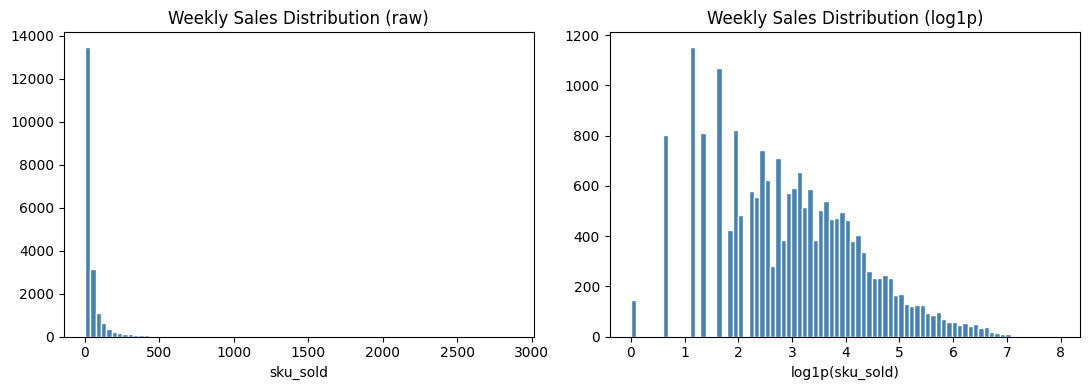

In [4]:
print("sku_sold distribution (weekly):")
print(df_model['sku_sold'].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 1.0]))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df_model['sku_sold'], bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Weekly Sales Distribution (raw)')
axes[0].set_xlabel('sku_sold')

axes[1].hist(np.log1p(df_model['sku_sold']), bins=80, color='steelblue', edgecolor='white')
axes[1].set_title('Weekly Sales Distribution (log1p)')
axes[1].set_xlabel('log1p(sku_sold)')

plt.tight_layout()
plt.show()

## 2. Monthly Seasonality

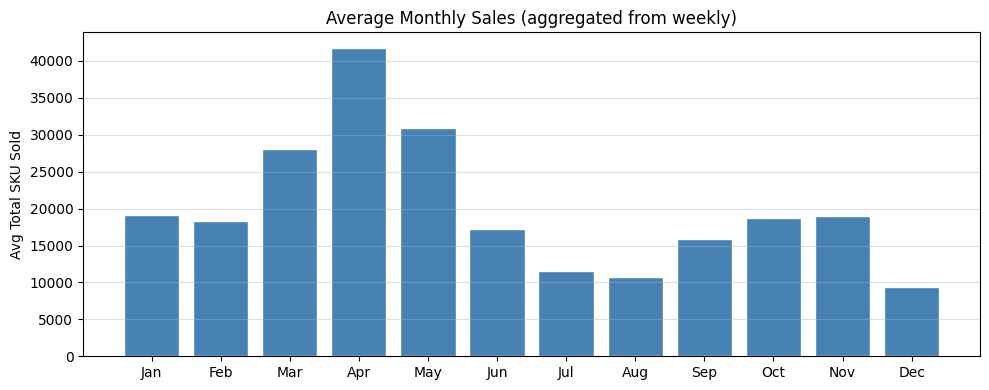

In [5]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

df_model['year']  = df_model['week_start'].dt.year
df_model['month'] = df_model['week_start'].dt.month

monthly = df_model.groupby(['year', 'month'])['sku_sold'].sum().reset_index()
month_avg = monthly.groupby('month')['sku_sold'].mean()

plt.figure(figsize=(10, 4))
plt.bar(month_names, month_avg.values, color='steelblue', edgecolor='white')
plt.title('Average Monthly Sales (aggregated from weekly)')
plt.ylabel('Avg Total SKU Sold')
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

## 3. Year-over-Year Comparison

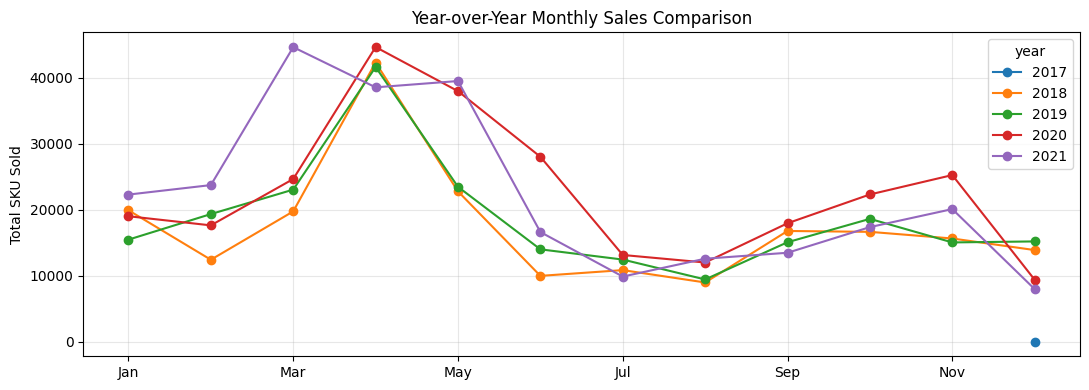

April sales by year:
year
2018    42314
2019    41636
2020    44657
2021    38557
Name: sku_sold, dtype: int64


In [6]:
monthly_pivot = monthly.pivot(index='month', columns='year', values='sku_sold')
monthly_pivot.index = month_names

monthly_pivot.plot(figsize=(11, 4), marker='o')
plt.title('Year-over-Year Monthly Sales Comparison')
plt.ylabel('Total SKU Sold')
plt.xlabel('')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# April anomaly (COVID)
print("April sales by year:")
print(monthly[monthly['month'] == 4].set_index('year')['sku_sold'])

## 4. Product Long-Tail & Pareto

Top 10 products account for 38.1% of total sales


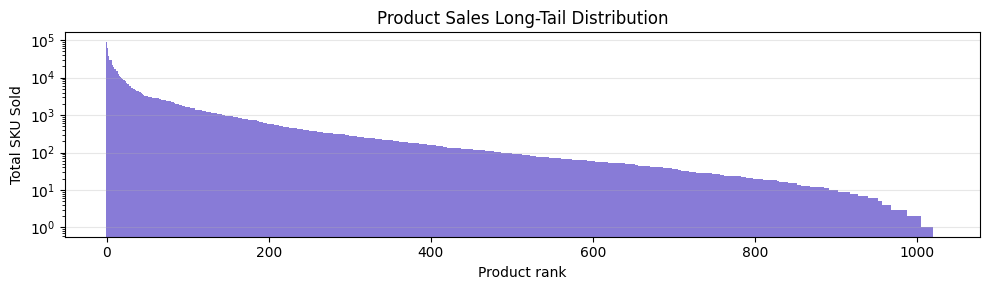

In [7]:
product_stats = (
    df_model.groupby('product_id')['sku_sold']
    .agg(total_sales='sum', mean_weekly='mean', std_weekly='std', weeks_active='count')
    .reset_index()
)
product_stats['cv'] = product_stats['std_weekly'] / product_stats['mean_weekly']
product_stats = product_stats.sort_values('total_sales', ascending=False).reset_index(drop=True)
product_stats['cumulative_pct'] = (
    product_stats['total_sales'].cumsum() / product_stats['total_sales'].sum() * 100
)

top10_pct = product_stats.head(10)['total_sales'].sum() / product_stats['total_sales'].sum() * 100
print(f"Top 10 products account for {top10_pct:.1f}% of total sales")

plt.figure(figsize=(10, 3))
plt.bar(range(len(product_stats)), product_stats['total_sales'].values,
        width=1.0, color='slateblue', alpha=0.8)
plt.title('Product Sales Long-Tail Distribution')
plt.xlabel('Product rank')
plt.ylabel('Total SKU Sold')
plt.yscale('log')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

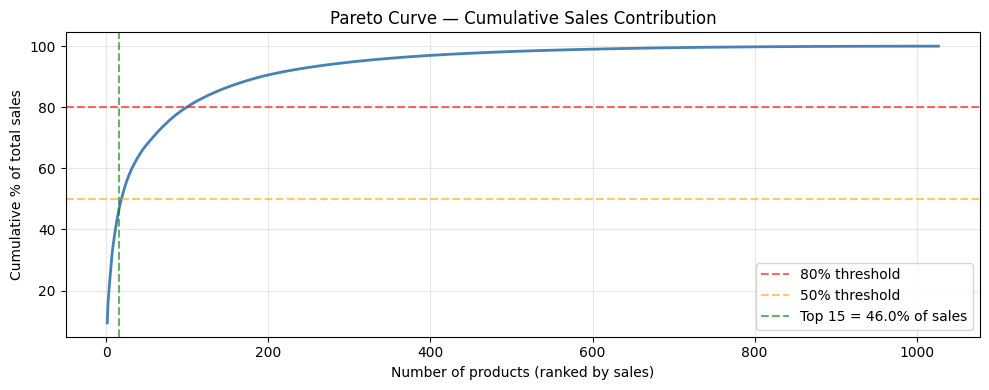

Products needed to cover 80% of sales: 99


In [8]:
TOP_N = 15
pct_at_top = product_stats.loc[TOP_N - 1, 'cumulative_pct']
n_for_80 = (product_stats['cumulative_pct'] < 80).sum() + 1

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(product_stats) + 1), product_stats['cumulative_pct'],
         color='steelblue', linewidth=2)
plt.axhline(80, color='red', linestyle='--', alpha=0.6, label='80% threshold')
plt.axhline(50, color='orange', linestyle='--', alpha=0.6, label='50% threshold')
plt.axvline(TOP_N, color='green', linestyle='--', alpha=0.6,
            label=f'Top {TOP_N} = {pct_at_top:.1f}% of sales')
plt.xlabel('Number of products (ranked by sales)')
plt.ylabel('Cumulative % of total sales')
plt.title('Pareto Curve — Cumulative Sales Contribution')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Products needed to cover 80% of sales: {n_for_80}")

## 5. Top 15 Products — Weekly Time Series

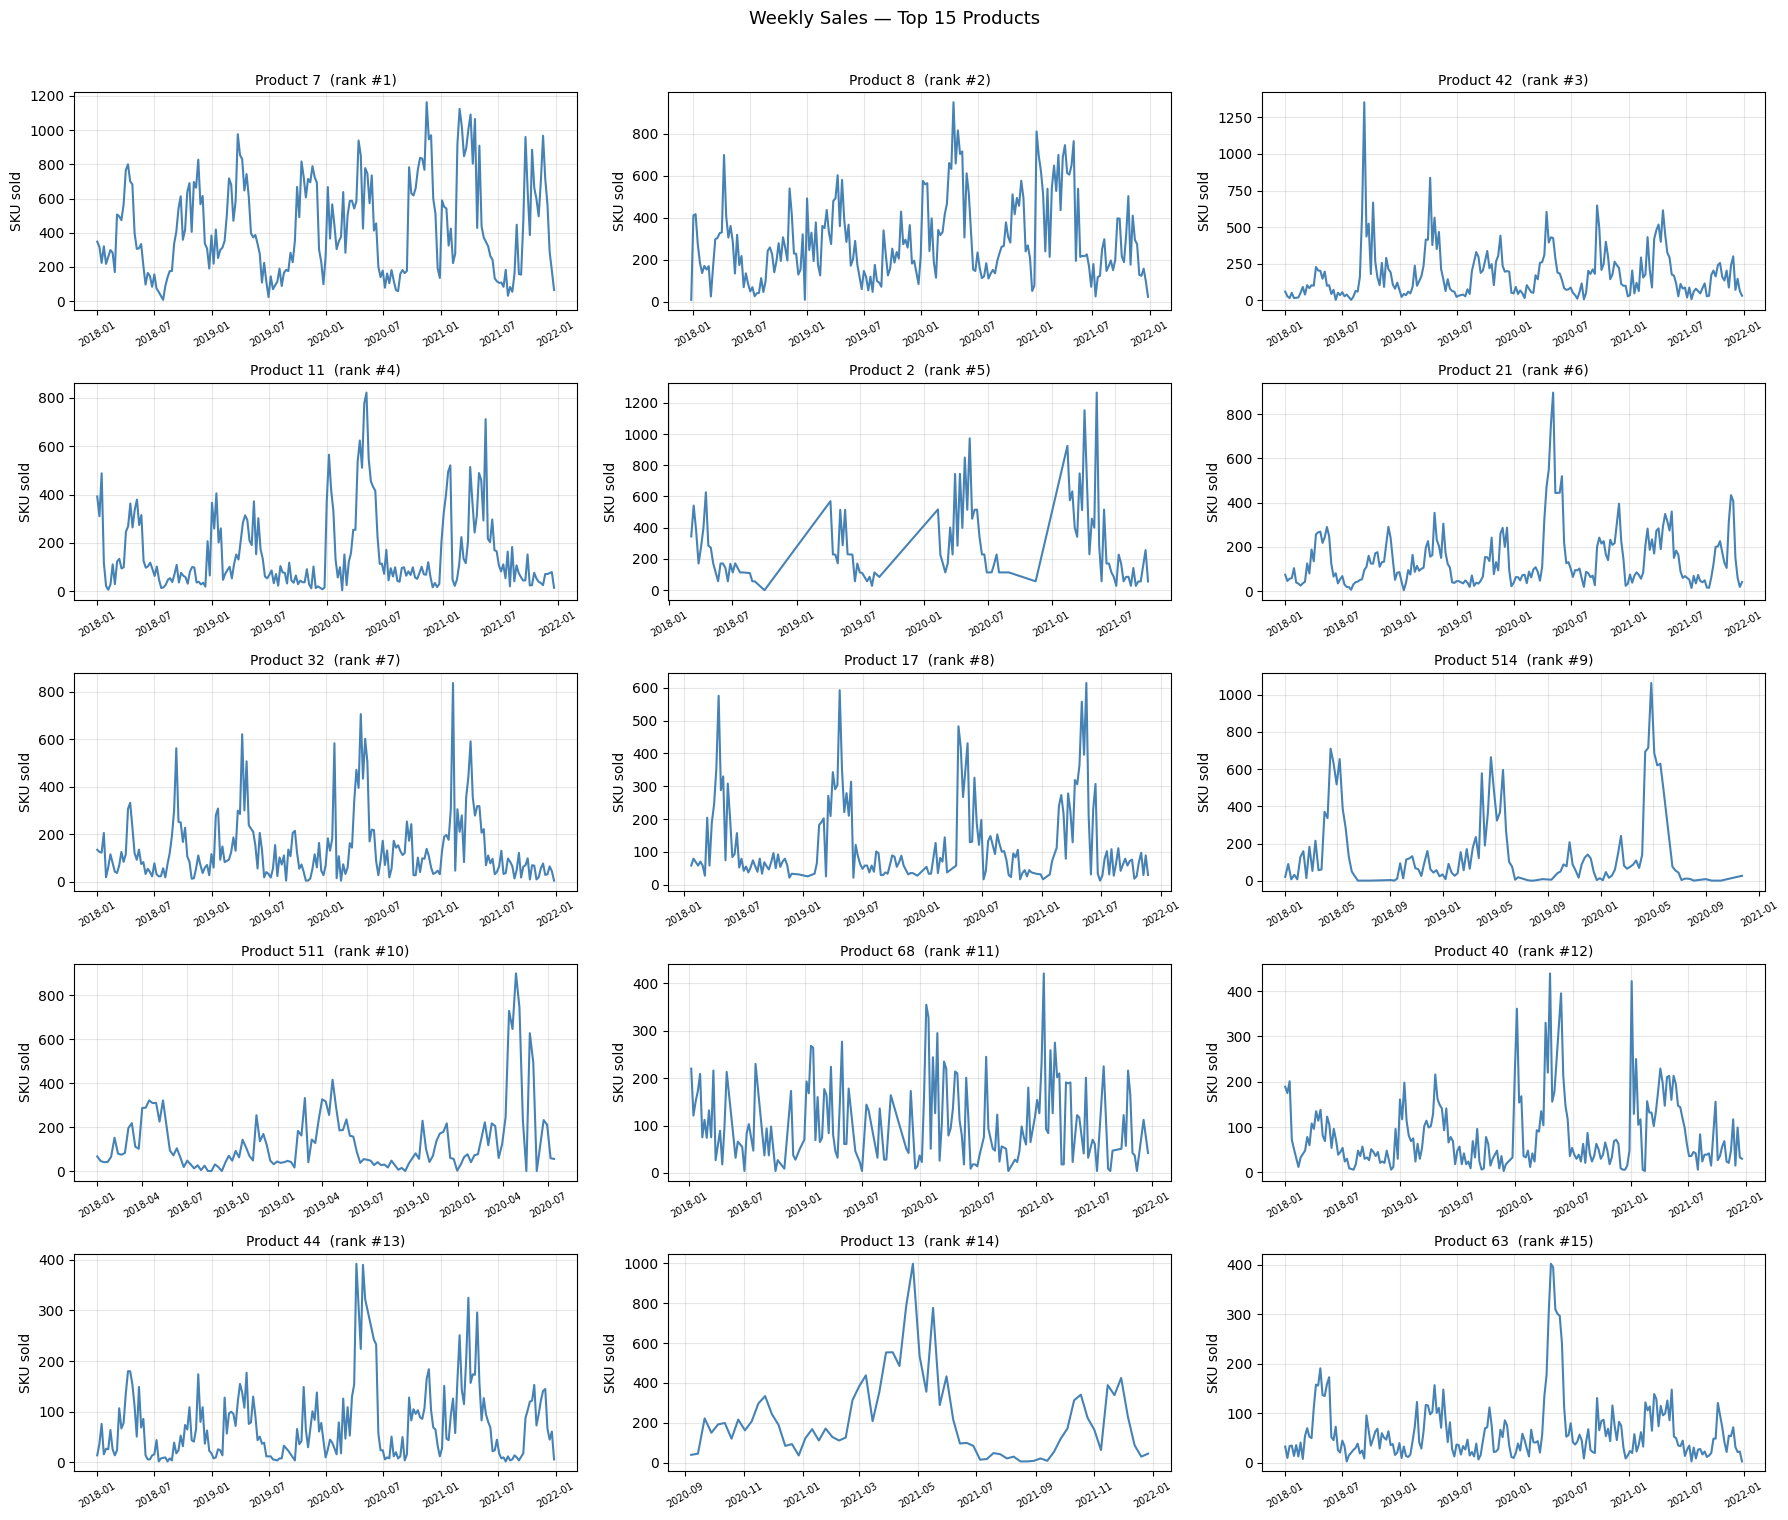

In [9]:
top_ids = product_stats.head(TOP_N)['product_id'].tolist()
df_top = df_model[df_model['product_id'].isin(top_ids)].sort_values(['product_id', 'week_start'])

n_cols = 3
n_rows = (TOP_N + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3))
axes = axes.flatten()

for i, pid in enumerate(top_ids):
    data = df_top[df_top['product_id'] == pid]
    axes[i].plot(data['week_start'], data['sku_sold'], linewidth=1.5, color='steelblue')
    axes[i].set_title(f'Product {pid}  (rank #{i+1})', fontsize=10)
    axes[i].set_ylabel('SKU sold')
    axes[i].grid(alpha=0.3)
    axes[i].tick_params(axis='x', rotation=30, labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Weekly Sales — Top {TOP_N} Products', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 6. Seasonality Heatmap

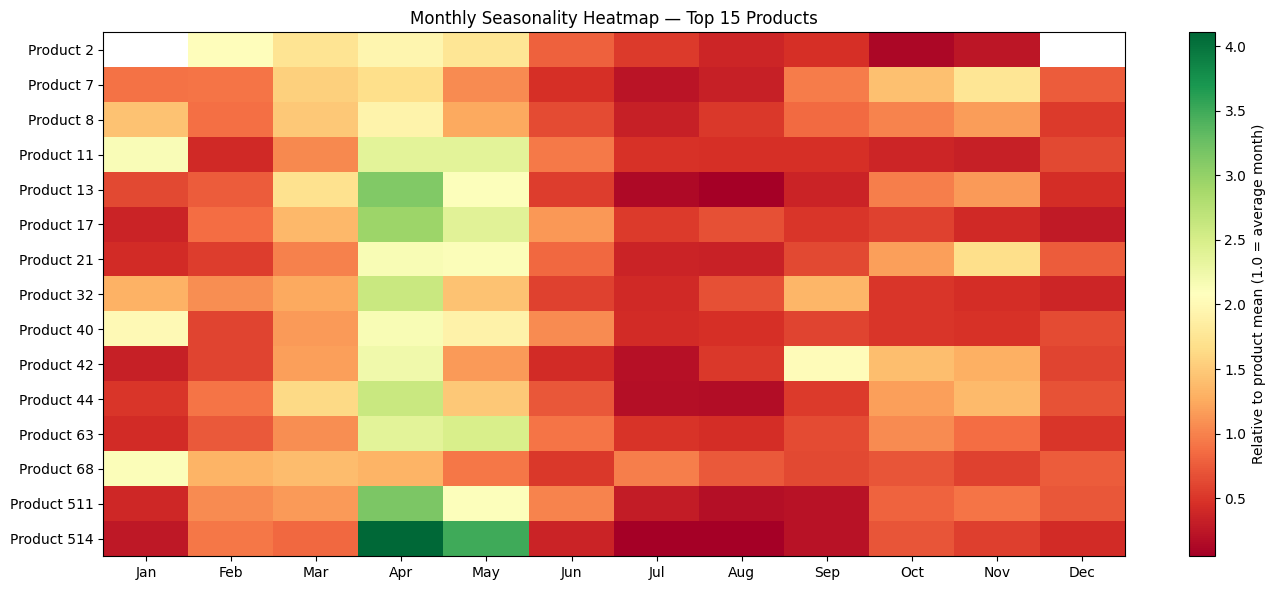

In [10]:
seasonality = (
    df_top.groupby(['product_id', 'month'])['sku_sold']
    .mean().reset_index()
)

pivot = seasonality.pivot(index='product_id', columns='month', values='sku_sold')
pivot.columns = month_names
pivot_norm = pivot.div(pivot.mean(axis=1), axis=0)

plt.figure(figsize=(14, 6))
im = plt.imshow(pivot_norm.values, aspect='auto', cmap='RdYlGn')
plt.colorbar(im, label='Relative to product mean (1.0 = average month)')
plt.xticks(range(12), month_names)
plt.yticks(range(len(pivot_norm)), [f'Product {p}' for p in pivot_norm.index])
plt.title(f'Monthly Seasonality Heatmap — Top {TOP_N} Products')
plt.tight_layout()
plt.show()

## 7. Product Landscape: Volume vs Volatility

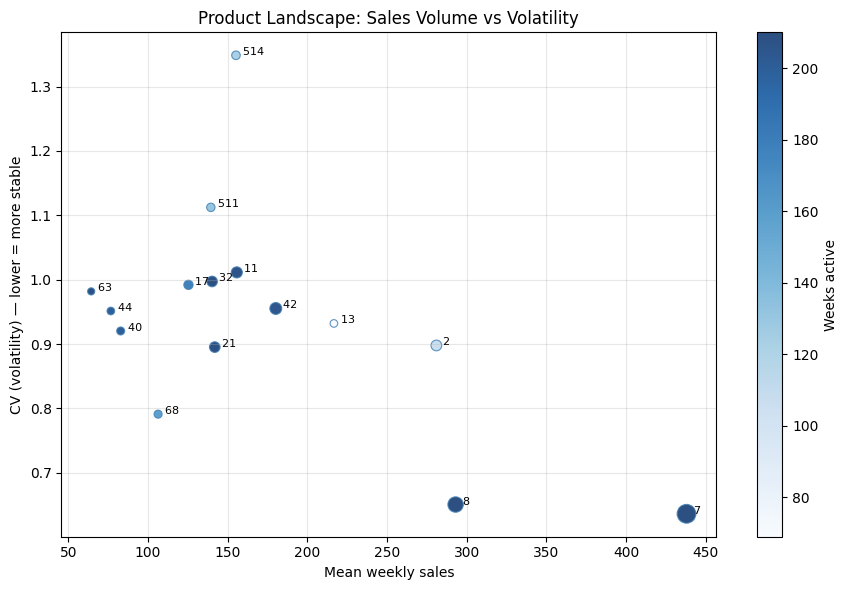

In [11]:
top_products = product_stats.head(TOP_N).copy()

plt.figure(figsize=(9, 6))
sc = plt.scatter(
    top_products['mean_weekly'],
    top_products['cv'],
    s=top_products['total_sales'] / 500,
    c=top_products['weeks_active'],
    cmap='Blues', edgecolors='steelblue', linewidths=0.8, alpha=0.85
)
plt.colorbar(sc, label='Weeks active')

for _, row in top_products.iterrows():
    plt.annotate(f"  {int(row['product_id'])}",
                 (row['mean_weekly'], row['cv']), fontsize=8)

plt.xlabel('Mean weekly sales')
plt.ylabel('CV (volatility) — lower = more stable')
plt.title('Product Landscape: Sales Volume vs Volatility')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Product Summary Table

In [12]:
seasonality_strength = (
    seasonality.groupby('product_id')['sku_sold']
    .agg(lambda x: x.std() / x.mean())
    .reset_index()
    .rename(columns={'sku_sold': 'seasonality_strength'})
)

summary = top_products.merge(seasonality_strength, on='product_id')
summary['sales_rank'] = summary['total_sales'].rank(ascending=False).astype(int)

print("=== High-Value Product Summary ===")
print(
    summary[['sales_rank','product_id','total_sales','mean_weekly',
              'cv','seasonality_strength','weeks_active']]
    .round(3)
    .to_string(index=False)
)

=== High-Value Product Summary ===
 sales_rank  product_id  total_sales  mean_weekly    cv  seasonality_strength  weeks_active
          1           7        91516      437.876 0.636                 0.518           209
          2           8        61527      292.986 0.651                 0.470           210
          3          42        36935      180.171 0.955                 0.667           205
          4          11        32228      155.691 1.011                 0.813           207
          5           2        29778      280.925 0.898                 0.779           106
          6          21        29510      141.875 0.895                 0.651           208
          7          32        29303      140.206 0.997                 0.650           209
          8          17        22190      125.367 0.992                 0.847           177
          9         514        19087      155.179 1.349                 1.346           123
         10         511        18261      139